# Importing Libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# 2. Hyperparameters

In [2]:
batch_size = 128
learning_rate = 0.001
epochs = 20

input_dim = 32 * 32 * 3
hidden_dim = 512

sparsity_target = 0.05
sparsity_weight = 1e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Explanation

This section defines the **training configuration and model parameters**.

| Parameter | Description |
|----------|-------------|
| batch_size | Number of images processed per training iteration |
| learning_rate | Controls how fast model weights are updated |
| epochs | Number of times the dataset is used during training |
| input_dim | Flattened CIFAR-10 image size (3072) |
| hidden_dim | Size of compressed feature representation |
| sparsity_target | Desired average activation of hidden neurons |
| sparsity_weight | Strength of sparsity regularization |

# 3.Load and Preprocess CIFAR-10 Dataset

In [3]:

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    transform=transform,
    download=True
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


100%|██████████| 170M/170M [00:04<00:00, 39.9MB/s]


### Explanation

Images are preprocessed before being fed to the network.

1. **ToTensor()**
   - Converts image pixels into PyTorch tensors.
   - Pixel values scaled from `[0,255]` to `[0,1]`.

2. **Normalize()**
   - Normalizes images around zero.
   - Helps neural networks train faster and more stably.

---

# Loading CIFAR-10 Dataset

### Explanation

This loads the **CIFAR-10 dataset**, which contains:

- **60,000 images**
- **10 object classes**
- Image size: **32 × 32 × 3**

Two datasets are created:

- **Training dataset**
- **Testing dataset**

---

`DataLoader` loads images in **mini-batches** during training.

Benefits:

- Efficient memory usage
- Faster training
- Automatic batching

Parameters used:

- **batch_size** – number of samples per batch
- **shuffle=True** – randomizes training samples

# 4. Sparse Autoencoder Model

In [4]:
class SparseAutoencoder(nn.Module):

    def __init__(self):
        super(SparseAutoencoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Sigmoid()
        )

        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()
        )

    def forward(self, x):

        encoded = self.encoder(x)
        decoded = self.decoder(encoded)

        return encoded, decoded

### Explanation

The autoencoder consists of two parts:

#### Encoder
Compresses the input image:

```
3072 → 512
```

It learns a **compact feature representation** of the input.

#### Decoder
Reconstructs the original image:

```
512 → 3072
```

It attempts to reproduce the input image from the compressed representation.


# 5. Sparsity Penalty Function

In [5]:
def sparsity_loss(encoded):

    eps = 1e-8

    rho_hat = torch.mean(encoded, dim=0)
    rho = torch.full_like(rho_hat, sparsity_target)

    rho_hat = torch.clamp(rho_hat, eps, 1 - eps)

    kl = rho * torch.log(rho / rho_hat) + \
         (1 - rho) * torch.log((1 - rho) / (1 - rho_hat))

    return torch.sum(kl)


### Explanation

Sparse autoencoders encourage **neurons to activate rarely**.

This is achieved using **KL Divergence**, which measures the difference between:

- Desired sparsity $ \rho $
- Actual neuron activation $ \hat{\rho} $

Loss function used during training:

$$
L = L_{\text{reconstruction}} + \lambda L_{\text{sparsity}}
$$

Where:

- $L_{\text{reconstruction}}$ = Mean Squared Error (MSE)
- $L_{\text{sparsity}}$ = KL divergence sparsity penalty
- $\lambda$ = sparsity regularization weight

# 6. Model Initialization

In [6]:
model = SparseAutoencoder().to(device)

criterion = nn.MSELoss()

optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [7]:
sparsity_values = [0, 1e-5, 1e-4, 1e-3]

results = {}

### Explanation

- **SparseAutoencoder()** – initializes the model
- **MSELoss()** – measures reconstruction error
- **Adam optimizer** – updates weights efficiently


# 7. Training the Autoencoder

In [8]:
def train_model(sparsity_weight):

    model = SparseAutoencoder().to(device)

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(epochs):

        total_loss = 0

        for images, _ in train_loader:

            images = images.view(images.size(0), -1).to(device)

            encoded, outputs = model(images)

            recon_loss = criterion(outputs, images)

            sp_loss = sparsity_loss(encoded)

            loss = recon_loss + sparsity_weight * sp_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        # average training loss
        avg_train_loss = total_loss / len(train_loader)

        print(f"Sparsity {sparsity_weight} | Epoch {epoch+1} Avg Loss {avg_train_loss:.4f}")


    model.eval()
    test_loss = 0

    with torch.no_grad():

        for images, _ in test_loader:

            images = images.view(images.size(0), -1).to(device)

            _, outputs = model(images)

            loss = criterion(outputs, images)

            test_loss += loss.item()

    # average test loss
    avg_test_loss = test_loss / len(test_loader)

    return model, avg_test_loss

### Explanation

Training process:

1. Images are **flattened into vectors**
2. Data passes through **encoder → decoder**
3. Two losses are calculated:
   - Reconstruction Loss
   - Sparsity Loss
4. Gradients are computed using **backpropagation**
5. Optimizer updates network weights


# Run Experiments

In [9]:
models = {}

for s in sparsity_values:

    print("\nRunning experiment with sparsity =", s)

    model, test_loss = train_model(s)

    results[s] = test_loss
    models[s] = model


Running experiment with sparsity = 0
Sparsity 0 | Epoch 1 Avg Loss 0.2045
Sparsity 0 | Epoch 2 Avg Loss 0.1761
Sparsity 0 | Epoch 3 Avg Loss 0.1673
Sparsity 0 | Epoch 4 Avg Loss 0.1628
Sparsity 0 | Epoch 5 Avg Loss 0.1597
Sparsity 0 | Epoch 6 Avg Loss 0.1577
Sparsity 0 | Epoch 7 Avg Loss 0.1561
Sparsity 0 | Epoch 8 Avg Loss 0.1549
Sparsity 0 | Epoch 9 Avg Loss 0.1539
Sparsity 0 | Epoch 10 Avg Loss 0.1533
Sparsity 0 | Epoch 11 Avg Loss 0.1525
Sparsity 0 | Epoch 12 Avg Loss 0.1520
Sparsity 0 | Epoch 13 Avg Loss 0.1516
Sparsity 0 | Epoch 14 Avg Loss 0.1511
Sparsity 0 | Epoch 15 Avg Loss 0.1508
Sparsity 0 | Epoch 16 Avg Loss 0.1505
Sparsity 0 | Epoch 17 Avg Loss 0.1502
Sparsity 0 | Epoch 18 Avg Loss 0.1499
Sparsity 0 | Epoch 19 Avg Loss 0.1496
Sparsity 0 | Epoch 20 Avg Loss 0.1494

Running experiment with sparsity = 1e-05
Sparsity 1e-05 | Epoch 1 Avg Loss 0.2079
Sparsity 1e-05 | Epoch 2 Avg Loss 0.1787
Sparsity 1e-05 | Epoch 3 Avg Loss 0.1699
Sparsity 1e-05 | Epoch 4 Avg Loss 0.1654
Spars

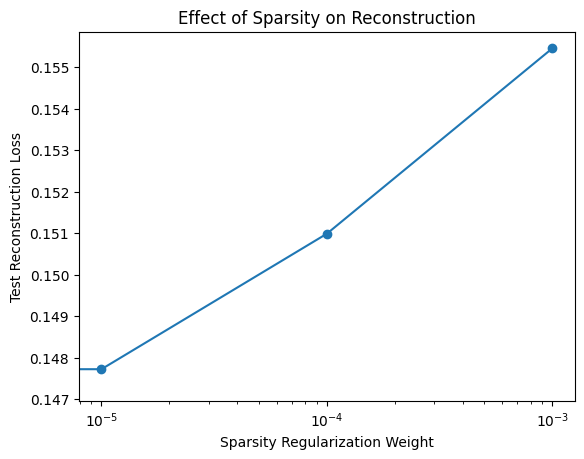

In [10]:
import matplotlib.pyplot as plt

x = list(results.keys())
y = list(results.values())

plt.plot(x, y, marker='o')

plt.xscale("log")

plt.xlabel("Sparsity Regularization Weight")
plt.ylabel("Test Reconstruction Loss")

plt.title("Effect of Sparsity on Reconstruction")

plt.show()

# 8. Evaluate on Test Data

In [11]:
criterion = nn.MSELoss()

for sparsity, model in models.items():

    model.eval()

    test_loss = 0

    with torch.no_grad():

        for images, _ in test_loader:

            images = images.view(images.size(0), -1).to(device)

            _, outputs = model(images)

            loss = criterion(outputs, images)

            test_loss += loss.item()

    avg_test_loss = test_loss / len(test_loader)

    print(f"Sparsity {sparsity} → Avg Test Reconstruction Loss: {avg_test_loss:.4f}")

Sparsity 0 → Avg Test Reconstruction Loss: 0.1474
Sparsity 1e-05 → Avg Test Reconstruction Loss: 0.1477
Sparsity 0.0001 → Avg Test Reconstruction Loss: 0.1510
Sparsity 0.001 → Avg Test Reconstruction Loss: 0.1555


### Explanation

The trained model is evaluated on **test data**.

- `model.eval()` switches the model to evaluation mode.
- `torch.no_grad()` disables gradient computation during testing.
- Reconstruction loss is calculated on unseen test images to measure how well the autoencoder generalizes.

---

## Reconstruction Loss Comparison (Average Loss)

| Sparsity Weight | Avg Test Reconstruction Loss |
|----------------|------------------------------|
| 0              | 0.1474                       |
| 1e-5           | 0.1477                       |
| 1e-4           | 0.1510                       |
| 1e-3           | 0.1555                       |

### Observation

The average reconstruction loss slightly increases as the sparsity regularization weight increases.

- **Lowest Loss:** `0` (0.1474)
- **Highest Loss:** `1e-3` (0.1555)

This indicates that stronger sparsity constraints slightly reduce the model's ability to reconstruct images accurately.

A very small sparsity value such as **1e-5** produces results almost identical to no sparsity, while higher sparsity values force more neurons to remain inactive, which reduces the model's capacity to represent detailed image information.

Overall, this experiment demonstrates the **trade-off between sparsity and reconstruction quality** in sparse autoencoders.

# 9. Visualize Original vs Reconstructed Images

In [12]:
def visualize(model, sparsity):

    dataiter = iter(test_loader)
    images, _ = next(dataiter)

    images = images.to(device)

    flat = images.view(images.size(0), -1)

    _, outputs = model(flat)

    outputs = outputs.view(-1,3,32,32)

    fig, axes = plt.subplots(2,6, figsize=(12,4))

    for i in range(6):

        axes[0,i].imshow(images[i].cpu().permute(1,2,0)*0.5 + 0.5)
        axes[0,i].set_title("Original")
        axes[0,i].axis("off")

        axes[1,i].imshow(outputs[i].cpu().detach().permute(1,2,0)*0.5 + 0.5)
        axes[1,i].set_title("Recon")
        axes[1,i].axis("off")

    plt.suptitle(f"Sparsity Weight = {sparsity}")
    plt.show()

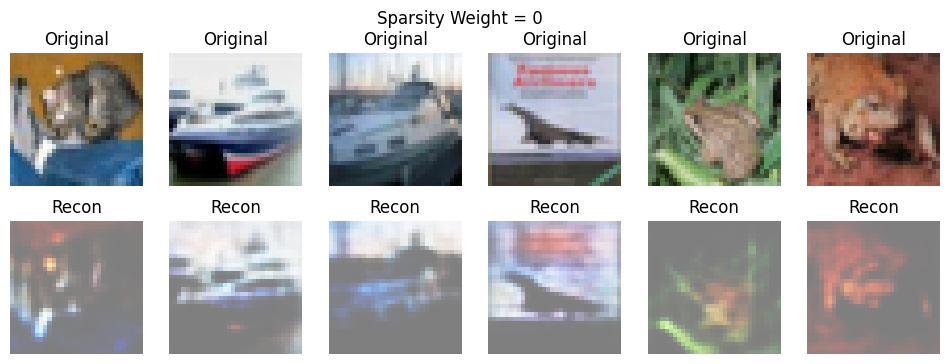

In [13]:
visualize(models[0], 0)


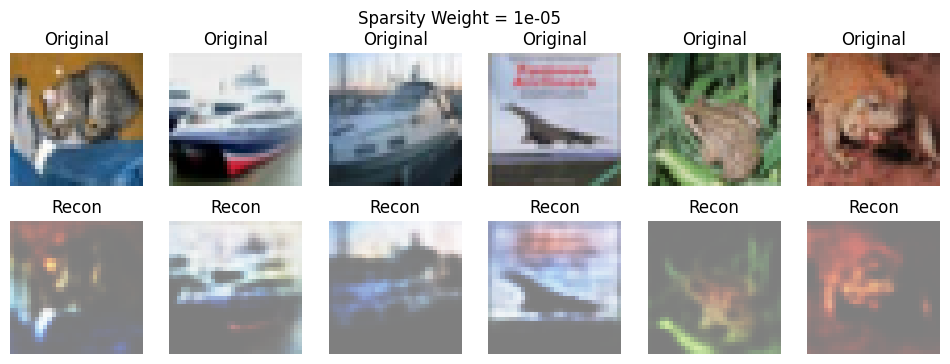

In [14]:
visualize(models[1e-5], 1e-5)


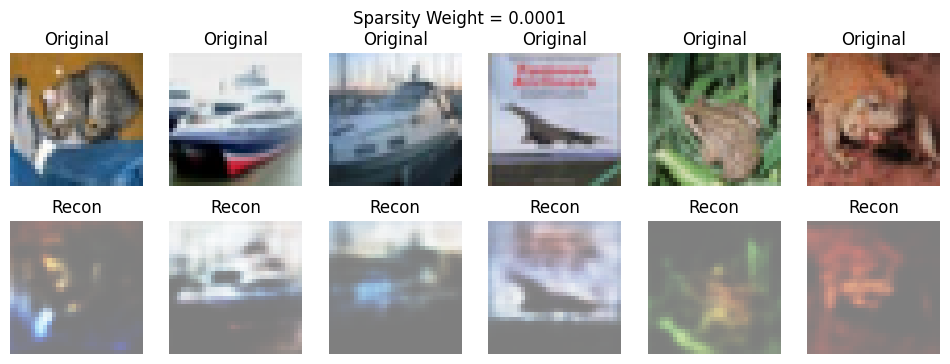

In [15]:
visualize(models[1e-4], 1e-4)

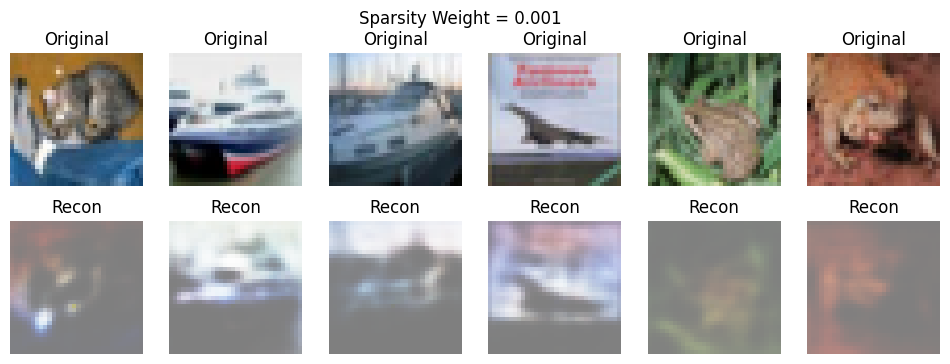

In [16]:

visualize(models[1e-3], 1e-3)

# Interpretation of Sparse Autoencoder Results

# Visual Reconstruction Analysis

The figures show original CIFAR-10 images in the first row and reconstructed images in the second row for different sparsity weights.

## Case 1 — Sparsity Weight = 0

- No sparsity constraint is applied.
- The autoencoder focuses purely on minimizing reconstruction error.
- Reconstructions appear slightly clearer compared to higher sparsity values.

**Observation:**  
The model allows many neurons to remain active, enabling it to capture more information about the image.

---

## Case 2 — Sparsity Weight = 1e-5

- A very small sparsity constraint is introduced.
- Reconstruction quality remains almost identical to the case without sparsity.

**Observation:**  
This value introduces a small sparsity constraint while maintaining nearly the same reconstruction quality as the baseline model.

---

## Case 3 — Sparsity Weight = 1e-4

- The sparsity constraint becomes stronger.
- Reconstructions appear slightly blurrier and lose some details.

**Observation:**  
More neurons are forced to remain inactive, reducing the model's ability to represent detailed image features.

---

## Case 4 — Sparsity Weight = 1e-3

- A strong sparsity constraint is applied.
- Reconstruction quality degrades noticeably.
- Images become darker and more blurred.

**Observation:**  
Too many neurons are forced to remain inactive, limiting the model's ability to reconstruct image information accurately.

---

# Overall Interpretation

The experiment demonstrates the trade-off between **sparsity and reconstruction quality**.

- Lower sparsity values allow better reconstruction because more neurons remain active.
- Higher sparsity values enforce stronger feature sparsity but reduce reconstruction quality.

### Total Loss Function

The total loss optimized by the model is:

$$
L = L_{\text{reconstruction}} + \lambda L_{\text{sparsity}}
$$

Where:

- $L_{\text{reconstruction}}$ represents the Mean Squared Error between the input and reconstructed images.
- $L_{\text{sparsity}}$ enforces sparse activation of hidden neurons.
- $\lambda$ controls the strength of sparsity regularization.

---

# Conclusion

From the experiment:

- **No sparsity constraint (0)** produced the lowest reconstruction loss.
- **Very small sparsity (1e-5)** achieved nearly identical performance while encouraging slight feature sparsity.
- Larger sparsity values (1e-4 and 1e-3) degraded reconstruction quality because too many neurons were forced to remain inactive.

Therefore, a **very small sparsity regularization** can provide a balance between sparse feature learning and reconstruction accuracy.